<a href="https://colab.research.google.com/github/LielUziahu/MDPI_S_Pistillata_Bet-Hedging/blob/main/Larval_Baseline_Physiology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Styling & Setup
Imports the required data science packages and sets the visual fingerprint (fonts, colors, and line weights) so the final plot perfectly matches previous  figures.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 20,      # Global title padding
    "axes.labelsize": 12,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "svg.fonttype": "none" # Protects text vectors for journal export
})
sns.set_theme(style="white", font="serif")

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}
global_box_width = 0.6
global_fig_size = (6, 8)
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6

# Centralized Asterisk & Significance Settings
global_asterisk_size = 12
global_asterisk_weight = 'bold'

# Added for significance mapping
def get_significance_label(p):
    if p < 0.001:
        return '***'
    elif p < 0.005:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

# Added for cleaner look
global_y_nbins = 3
global_edgecolor = 'black'
global_line_width = 1.5

print(f"Global styling initialized. Significance mapping (p < 0.05: *, 0.005: **, 0.001: ***) added.")

Global styling initialized. Significance mapping (p < 0.05: *, 0.005: **, 0.001: ***) added.


# Release Pattarn by morph

## Block 1: Data Loading & Filtering
We need to load the Release_Data.csv and focus strictly on the HF vs NF comparison, ignoring the 'PF' (if present) to keep the comparison clean.

In [2]:
# Load the data
df = pd.read_csv('Release_Data.csv')

# Focus only on HF and NF for this plot
df_filtered = df[df['morph'].isin(['HF', 'NF'])].copy()

# Print the data to double-check
print("Data Preview:")
print(df_filtered.head())

Data Preview:
  colony morph  total released  % from total coloney
0      A    HF             199             50.636132
2      A    NF              30              7.633588
3      B    HF              23             39.655172
5      B    NF              13             38.235294
6      C    HF             621             29.913295


## Block 3: Normality-Driven Statistical Engine
It checks the distribution of the differences between HF and NF, which is the correct statistical approach for paired data.

In [3]:
# --- BLOCK 3: ROBUST STATISTICAL ANALYSIS ---

# Prepare data for paired comparison (pivot)
df_pivot = df_filtered.pivot_table(index='colony', columns='morph', values='total released')

# 1. Calculate the differences
df_diff = df_pivot[('HF')] - df_pivot[('NF')]

# 2. Shapiro-Wilk Test for Normality on the differences
stat_norm, p_norm = stats.shapiro(df_diff)

print(f"Normality test (Shapiro-Wilk) on paired differences: p = {p_norm:.4f}")

# 3. Decision Logic
if p_norm > 0.05:
    print("Result: Data is normally distributed. Running Paired T-test.")
    stat, p_val = stats.ttest_rel(df_pivot[('HF')],
                                  df_pivot[('NF')])
    test_name = "Paired T-test"
else:
    print("Result: Data is NOT normal. Running Wilcoxon Signed-Rank Test.")
    stat, p_val = stats.wilcoxon(df_pivot[('HF')],
                                 df_pivot[('NF')])
    test_name = "Wilcoxon Signed-Rank"

print(f"Selected Test: {test_name}")
print(f"p-value: {p_val:.4f}")

# Store this for the poster visualization
stats_report = f"{test_name}\n p = {p_val:.4f}"

Normality test (Shapiro-Wilk) on paired differences: p = 0.0063
Result: Data is NOT normal. Running Wilcoxon Signed-Rank Test.
Selected Test: Wilcoxon Signed-Rank
p-value: 0.0156


## Plotting

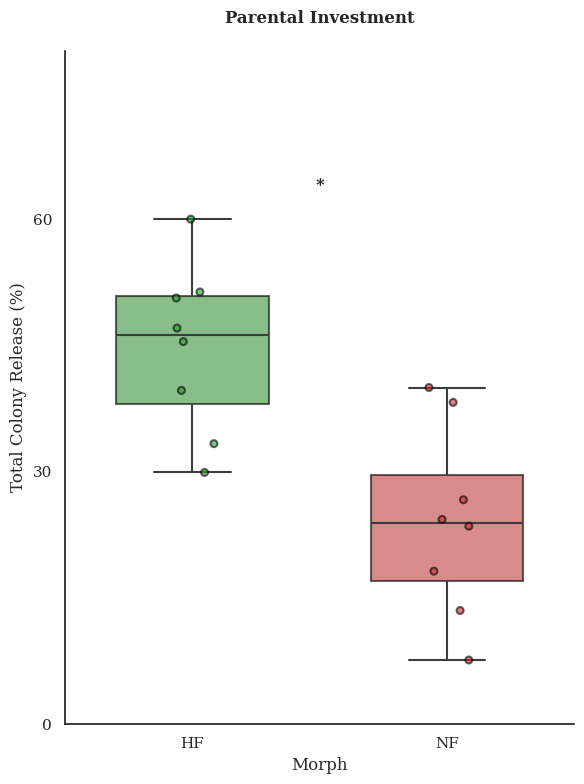

In [4]:

# --- BLOCK: PAIRED RELEASE DATA PLOT (PERCENTAGE) ---

plt.figure(figsize=global_fig_size)

# 1. Boxplot
ax = sns.boxplot(
    data=df_filtered,
    x='morph',
    y='% from total coloney',
    palette=variant_colors,
    hue='morph',
    width=global_box_width,
    showfliers=False,
    linewidth=global_line_width,
    legend=False,
    boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}
)

# 2. Stripplot
sns.stripplot(
    data=df_filtered,
    x='morph',
    y='% from total coloney',
    hue='morph',
    palette=variant_colors,
    size=global_marker_size,
    jitter=global_jitter,
    alpha=global_alpha,
    zorder=5,
    legend=False,
    edgecolor=global_edgecolor,
    linewidth=global_line_width
)

# 3. Dynamic Significance Marker
# Using p_val from Block 3 and the global significance label function
sig_label = get_significance_label(p_val)
plt.text(0.5, df_filtered['% from total coloney'].max() * 1.05,
         sig_label,
         ha='center',
         va='bottom',
         fontsize=global_asterisk_size,
         fontweight=global_asterisk_weight)

# Final Touches
plt.title("Parental Investment", fontweight="bold")
plt.ylabel("Total Colony Release (%)")
plt.xlabel("Morph")
ax.yaxis.set_major_locator(plt.MaxNLocator(global_y_nbins))
plt.ylim(0, 80)
sns.despine()

plt.tight_layout()
#plt.savefig("Morph Release.png", format="png", dpi=600)
plt.show()

# GFP Intensity

## Block 1: Load Data & Outlier Removal
Loading Data and remoiving outliers using the 1.5 IQR method to ensure robust statistical analysis and visualization. This step is performed after initial data loading and filtering.


In [5]:
# Load your data
df = pd.read_csv('GFP_raw_sum_normalized.csv')
# Keep only HF and NF for analysis
df_gfp = df[df['Variant'].isin(['HF', 'NF'])].copy()
print("Data loaded successfully.")

# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'Intensity_per_µm2'
Q1 = df_gfp['Intensity_per_µm2'].quantile(0.25)
Q3 = df_gfp['Intensity_per_µm2'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_gfp_cleaned = df_gfp[(df_gfp['Intensity_per_µm2'] >= lower_bound) & (df_gfp['Intensity_per_µm2'] <= upper_bound)]

print(f"Original number of data points: {len(df_gfp)}")
print(f"Number of data points after outlier removal: {len(df_gfp_cleaned)}")

# Update df_gfp to the cleaned version for subsequent analysis
df_gfp = df_gfp_cleaned.copy()

print("Outliers removed and df_gfp updated.")

Data loaded successfully.
Original number of data points: 21
Number of data points after outlier removal: 21
Outliers removed and df_gfp updated.


## Block 2: Normality Check
It is standard practice to check if your data is normally distributed before choosing a statistical test.

In [6]:
hf_data = df_gfp[df_gfp['Variant'] == 'HF']['Intensity_per_µm2']
nf_data = df_gfp[df_gfp['Variant'] == 'NF']['Intensity_per_µm2']

# Shapiro-Wilk test
stat_hf, p_hf = stats.shapiro(hf_data)
stat_nf, p_nf = stats.shapiro(nf_data)

print(f"Normality Test - HF: p={p_hf:.4f}, NF: p={p_nf:.4f}")

Normality Test - HF: p=0.9369, NF: p=0.0738


## Block 3: Statistical Test
Based on the normality result, we Auto-select the appropriate test.

In [7]:
# Select test: T-test if normal (p > 0.05), Mann-Whitney if not (p < 0.05)
if p_hf < 0.05 or p_nf < 0.05:
    test_type = "Mann-Whitney U"
    stat, p_val = stats.mannwhitneyu(hf_data, nf_data)
else:
    test_type = "Independent T-test"
    stat, p_val = stats.ttest_ind(hf_data, nf_data)

print(f"Test used: {test_type}")
print(f"p-value: {p_val:.4e}")

Test used: Independent T-test
p-value: 1.1467e-08


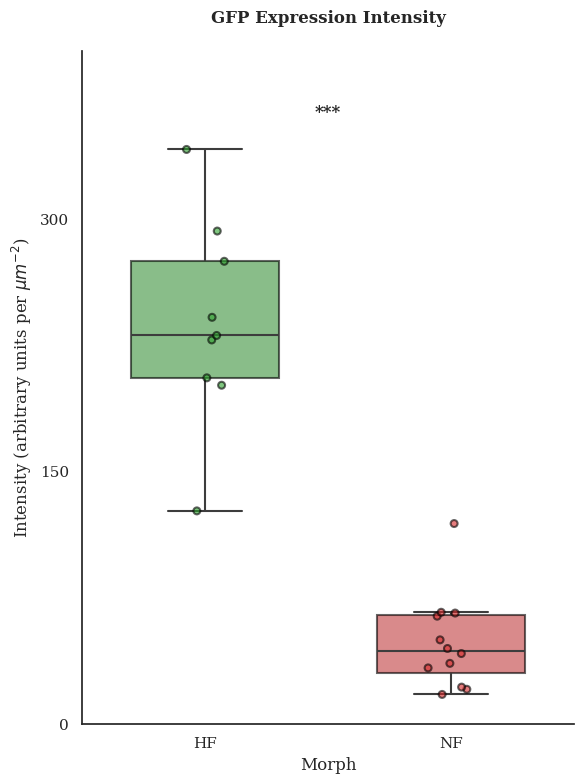

In [8]:
# --- BLOCK: GFP INTENSITY DATA PLOT ---

plt.figure(figsize=global_fig_size)

# 1. Boxplot
ax = sns.boxplot(
    data=df_gfp,
    x='Variant',
    y='Intensity_per_µm2',
    palette=variant_colors,
    hue='Variant',
    width=global_box_width,
    showfliers=False,
    linewidth=global_line_width,
    legend=False,
    boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}
)

# 2. Stripplot
sns.stripplot(
    data=df_gfp,
    x='Variant',
    y='Intensity_per_µm2',
    hue='Variant',
    palette=variant_colors,
    size=global_marker_size,
    jitter=global_jitter,
    alpha=global_alpha,
    zorder=5,
    legend=False,
    edgecolor=global_edgecolor,
    linewidth=global_line_width
)

# 3. Dynamic Significance Marker
sig_label = get_significance_label(p_val)
plt.text(0.5, df_gfp['Intensity_per_µm2'].max() * 1.05,
         sig_label,
         ha='center',
         va='bottom',
         fontsize=global_asterisk_size,
         fontweight=global_asterisk_weight)

# Final Touches
plt.title("GFP Expression Intensity", fontweight="bold")
plt.ylabel(r"Intensity (arbitrary units per $\mu m^{-2}$)")
plt.xlabel("Morph")
ax.yaxis.set_major_locator(plt.MaxNLocator(global_y_nbins))
plt.ylim(0, 400)
sns.despine()
plt.tight_layout()
#plt.savefig("GFP_Intensity_Plot.png", format="png", dpi=600)
plt.show()

# Planulae Volume

## Block 1: Setup & Load 2026 Data
loads dataset, stripping any hidden spaces from the columns.

In [9]:

# 1. Load 2026 Data
file_2026 = 'Planulae size 2026.csv'
df26 = pd.read_csv(file_2026, encoding='latin-1')
df26.columns = df26.columns.str.strip()


## Block 2: Geometric Filtering
Recalculate the dimensions from your ImageJ Area and Perimeter outputs to filter out any planulae that were imaged horizontally (Aspect Ratio < 2.5).

In [10]:
# 2. Geometric Filtering (Aspect Ratio >= 2.5)
A = df26['area µm²']
P = df26['perimeter µm']
r = (P - np.sqrt(P**2 - 4 * np.pi * A)) / (2 * np.pi)
w = 2 * r
L_total = ((P - 2 * np.pi * r) / 2) + (2 * r)
df26['Aspect_Ratio'] = L_total / w

# Split data into removed vs good
df26_removed_ratio = df26[df26['Aspect_Ratio'] < 2.5]
df26_good = df26[df26['Aspect_Ratio'] >= 2.5].copy()

## Block 3: Remove 1.5 IQR Outliers
This sweeps the dataset to find any extreme volume measurements per morphotype (HF vs. NF).

In [11]:
# 3. Remove 1.5 IQR outliers per group
def remove_outliers(df, group_col, val_col):
    outliers_list = []
    clean_data_list = []

    for name, group in df.groupby(group_col):
        Q1 = group[val_col].quantile(0.25)
        Q3 = group[val_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter rows
        outliers = group[(group[val_col] < lower_bound) | (group[val_col] > upper_bound)]
        clean = group[(group[val_col] >= lower_bound) & (group[val_col] <= upper_bound)]

        outliers_list.append(outliers)
        clean_data_list.append(clean)

    return pd.concat(clean_data_list), pd.concat(outliers_list)

# Apply filter specifically to Volume
df26_clean, df26_outliers = remove_outliers(df26_good, 'morph', 'Volume mm³')

# Print Data Removal Report
print("--- 2026 DATA REMOVAL REPORT ---")
print(f"Total larvae ignored due to Aspect Ratio < 2.5: {len(df26_removed_ratio)}")
if not df26_removed_ratio.empty:
    print(df26_removed_ratio[['no', 'morph', 'Label', 'Aspect_Ratio']])
print("-" * 40)

print(f"Total outliers removed (1.5 IQR): {len(df26_outliers)}")
if not df26_outliers.empty:
    print(df26_outliers[['no', 'morph', 'Label', 'Volume mm³']])
print("-" * 40)
print(f"Total larvae remaining for analysis: {len(df26_clean)}")

--- 2026 DATA REMOVAL REPORT ---
Total larvae ignored due to Aspect Ratio < 2.5: 4
      no morph  Label  Aspect_Ratio
50    51    HF      1      1.783012
81    82    HF     11      2.254283
94    95    NF      2      2.248411
101  102    NF      4      1.653646
----------------------------------------
Total outliers removed (1.5 IQR): 9
      no morph  Label  Volume mm³
5      6    HF      2      0.4590
8      9    HF      1      0.4795
12    13    HF      2      0.4758
14    15    HF      2      0.4609
16    17    HF      2      0.1601
24    25    HF      3      0.1490
48    49    HF      5      0.5298
54    55    HF      5      0.4530
109  110    NF      2      0.4689
----------------------------------------
Total larvae remaining for analysis: 125


## Block 4: Normality Test
Evaluates if the volume distribution of HF and NF cohorts follow a normal Gaussian curve using the Shapiro-Wilk test.

In [12]:
# 5. Normality Test & Diagnostic Plots
import matplotlib.ticker as ticker

unique_morphs = df26_clean['morph'].unique()
print("\n--- 2026 NORMALITY TEST (Cleaned Data) ---")
normality_results = {}


for i, morph in enumerate(unique_morphs):
    data = df26_clean[df26_clean['morph'] == morph]['Volume mm³'].dropna()

    # Statistical Test
    shapiro_p = stats.shapiro(data)[1]
    is_normal = shapiro_p > 0.05
    normality_results[morph] = is_normal

    result = "Normal ✅" if is_normal else "NOT Normal ❌"
    print(f"Morph: {morph} (n={len(data)}) | Shapiro-Wilk p-value: {shapiro_p:.5f} | {result}")




--- 2026 NORMALITY TEST (Cleaned Data) ---
Morph: HF (n=82) | Shapiro-Wilk p-value: 0.96090 | Normal ✅
Morph: NF (n=43) | Shapiro-Wilk p-value: 0.66581 | Normal ✅


## Block 5: Automated Statistical Decision & Summary
Automatically reads the output of Block 5. If both groups are normal, it runs a T-test; if either group is skewed, it defaults to the non-parametric Mann-Whitney U test.

In [13]:
# 5. Statistical test based on normality & 7. Full statistical summary
print("\n--- STATISTICAL COMPARISON SUMMARY ---")
morphs = list(normality_results.keys())

if len(morphs) == 2:
    group1 = df26_clean[df26_clean['morph'] == morphs[0]]['Volume mm³'].dropna()
    group2 = df26_clean[df26_clean['morph'] == morphs[1]]['Volume mm³'].dropna()

    # Logic gate for stats
    if all(normality_results.values()):
        print("Verdict: Both groups are normally distributed.")
        stat, p_val = stats.ttest_ind(group1, group2)
        test_used = "Independent T-test"
    else:
        print("Verdict: Non-normal distribution detected.")
        stat, p_val = stats.mannwhitneyu(group1, group2)
        test_used = "Mann-Whitney U"

    significance = "Significant ⭐" if p_val < 0.05 else "Not Significant (NS)"

    # 7. Summary
    print(f"\nComparison: {morphs[0]} vs {morphs[1]}")
    print(f"Test Used: {test_used}")
    print(f"Statistic: {stat:.5f}")
    print(f"p-value: {p_val:.5e} | {significance}")
else:
    print("More than 2 morphs detected. Code requires adjustment for ANOVA/Kruskal-Wallis.")


--- STATISTICAL COMPARISON SUMMARY ---
Verdict: Both groups are normally distributed.

Comparison: HF vs NF
Test Used: Independent T-test
Statistic: 3.00522
p-value: 3.21720e-03 | Significant ⭐


## Block 8: Global Style Plotting
Creates a publication-ready figure Boxplot with jittered dots to show the exact spread of HF vs. NF volume.

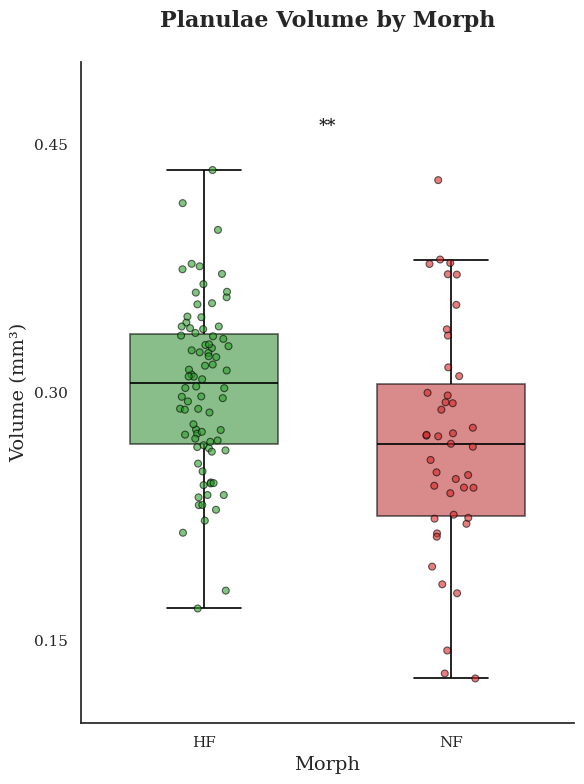

In [14]:
fig, ax_box = plt.subplots(figsize=global_fig_size)

plot_order = [m for m in ['HF', 'NF'] if m in df26_clean['morph'].unique()]

# Main comparison plot
sns.boxplot(
    data=df26_clean,
    x='morph',
    y='Volume mm\u00b3',
    order=plot_order,
    hue='morph',
    palette=variant_colors,
    ax=ax_box,
    showfliers=False,
    legend=False,
    width=global_box_width,
    boxprops=dict(edgecolor="black", linewidth=1.2, alpha=0.6),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2),
    medianprops=dict(color="black", linewidth=1.2)
)

# Jittered points
sns.stripplot(
    data=df26_clean,
    x='morph',
    y='Volume mm\u00b3',
    order=plot_order,
    hue='morph',
    palette=variant_colors,
    alpha=global_alpha,
    jitter=global_jitter,
    size=global_marker_size,
    ax=ax_box,
    legend=False,
    linewidth=0.8,
    edgecolor='black'
)

# --- SIGNIFICANCE ANNOTATION (using global function) ---
if 'p_val' in globals():
    sig_str = get_significance_label(p_val)

    if sig_str != 'n.s.':
        x1, x2 = 0, 1
        y_max = df26_clean['Volume mm\u00b3'].max()
        h_ast = y_max * 1.05
        ax_box.text((x1+x2)*.5, h_ast, sig_str,
                    ha='center', va='bottom',
                    fontsize=global_asterisk_size,
                    fontweight=global_asterisk_weight)

# Labels and Ticks
ax_box.set_title("Planulae Volume by Morph", fontsize=16, fontweight=global_asterisk_weight, pad=25)
ax_box.set_ylabel("Volume (mm\u00b3)", fontsize=14)
ax_box.set_xlabel("Morph", fontsize=14)
ax_box.set_ylim(0.1, 0.5)
ax_box.yaxis.set_major_locator(ticker.MaxNLocator(nbins=global_y_nbins))

sns.despine()
plt.tight_layout()

# Save the plot at 600 DPI
#lt.savefig("Planulae_Volume_Plot.png", format="png", dpi=600)

plt.show()

# Respiration Rate

## Block 1: Loading Data and combining expirimantal loadout with Oxygen raw data

In [15]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# 1. Load data files securely using the Latin1 text layout decoder
df_oxy = pd.read_csv('oxy16042026_Oxygen.csv', encoding='latin1')
df_load = pd.read_csv('loadout.csv', encoding='latin1')

# 2. Convert the 2D loadout grid template into a flat coordinate map
df_load = df_load.set_index('Unnamed: 0')
well_morph_lookup = {}

for row_letter in df_load.index:
    for col_number in ['1', '2', '3', '4', '5', '6']:
        well_coordinate = f"{row_letter}{col_number}"
        morphtype = df_load.loc[row_letter, col_number]
        well_morph_lookup[well_coordinate] = morphtype

# 3. Target all possible well channels across the 24-well configuration plate
target_channels = [f"{r}{c}" for r in ['A', 'B', 'C', 'D'] for c in range(1, 7)]
compiled_dataset = []

# 4. Loop through each target channel, isolate values, and process active rates
for channel in target_channels:
    if channel in df_oxy.columns:
        # Isolate the targeted timeline slice and scrub empty cells
        data_slice = df_oxy[['Time/Min.', channel]].dropna()

        # Enforce strict float properties to block text parsing anomalies
        time_data = pd.to_numeric(data_slice['Time/Min.'], errors='coerce')
        oxy_data = pd.to_numeric(data_slice[channel], errors='coerce')

        # Clean out any remaining missing values after conversion
        valid_indices = time_data.notna() & oxy_data.notna()
        time_clean = time_data[valid_indices]
        oxy_clean = oxy_data[valid_indices]

        if len(time_clean) > 1:
            # Perform ordinary least squares regression
            slope, intercept, r_value, p_value, std_err = linregress(time_clean, oxy_clean)

            # Append rows, inverting the rate slope parameter into consumption speed
            compiled_dataset.append({
                'Well': channel,
                'Morph': well_morph_lookup.get(channel, 'Unknown'),
                'Respiration_Rate_umol_L_min': -slope,
                'R_Squared': r_value ** 2
            })

# 5. Build the clean, long-format final dataframe structure
df_planula_respiration = pd.DataFrame(compiled_dataset)

# 6. Display primary processing metrics directly inside the workspace window
print("--- FIRST 10 INTEGRATED SAMPLES ---")
print(df_planula_respiration.head(10).to_string(index=False))

print("\n--- GLOBAL AGGREGATED SUMMARY LOGS ---")
summary = df_planula_respiration.groupby('Morph')['Respiration_Rate_umol_L_min'].agg(['count', 'mean', 'std', 'min', 'max'])
print(summary)

# 7. Export the final long-format output structure to your workspace directory
df_planula_respiration.to_csv('Planula_Baseline_Respiration_Processed.csv', index=False)

--- FIRST 10 INTEGRATED SAMPLES ---
Well Morph  Respiration_Rate_umol_L_min  R_Squared
  A1    HF                     0.404921   0.958150
  A2    HF                     1.013406   0.976984
  A3    HF                     1.144284   0.986136
  A4    NF                     1.598505   0.982093
  A5    NF                     1.862354   0.973296
  A6 blank                    -0.023313   0.389262
  B1    HF                     1.188499   0.966387
  B2    HF                     1.474413   0.980757
  B3    HF                     1.518870   0.978700
  B4    NF                     1.798730   0.991471

--- GLOBAL AGGREGATED SUMMARY LOGS ---
       count      mean       std       min       max
Morph                                               
HF        10  1.501288  0.804601  0.404921  3.142877
NF        10  1.636851  0.596712  0.727637  2.936219
blank      4  0.002226  0.044015 -0.023313  0.067945


## Block 2: Substracting Avarge Blank From all Samples


In [16]:
import pandas as pd

# 1. Calculate the mean respiration rate of the blanks
blank_avg = df_planula_respiration[df_planula_respiration['Morph'] == 'blank']['Respiration_Rate_umol_L_min'].mean()
print(f"Average Blank Respiration Rate (Baseline): {blank_avg:.6f} umol/L/min")

# 2. Correct for baseline and divide by 3 (since there are 3 planulae per well)
# This gives us the rate per individual planula
df_planula_respiration['Corrected_Respiration_Rate_per_Planula'] = (df_planula_respiration['Respiration_Rate_umol_L_min'] - blank_avg) / 3

# 3. Filter to keep only experimental samples (removing blanks) for analysis
df_respiration_corrected = df_planula_respiration[df_planula_respiration['Morph'] != 'blank'].copy()

# 4. Display the updated summary
print("\n--- GLOBAL AGGREGATED SUMMARY (RATE PER PLANULA) ---")
summary_corrected = df_respiration_corrected.groupby('Morph')['Corrected_Respiration_Rate_per_Planula'].agg(['count', 'mean', 'std', 'min', 'max'])
display(summary_corrected)

# 5. Export the corrected data
df_respiration_corrected.to_csv('Planula_Respiration_Corrected.csv', index=False)

Average Blank Respiration Rate (Baseline): 0.002226 umol/L/min

--- GLOBAL AGGREGATED SUMMARY (RATE PER PLANULA) ---


,count,mean,std,min,max
Morph,,,,,
HF,10,0.499687,0.268200,0.134232,1.046884
NF,10,0.544875,0.198904,0.241803,0.977998


## Block 3: Normelizing Raspiration Rate by Volume

In [17]:
# --- BLOCK: VOLUME-SPECIFIC RESPIRATION NORMALIZATION ---

# 1. Calculate average volume per morph from the cleaned 2026 volume data
avg_volume = df26_clean.groupby('morph')['Volume mm³'].mean()
print("Average Volume per Morph (mm³):")
print(avg_volume)

# 2. Map these volumes to the respiration dataframe and divide
df_respiration_corrected['Avg_Morph_Volume_mm3'] = df_respiration_corrected['Morph'].map(avg_volume)
df_respiration_corrected['Respiration_Rate_per_mm3'] = (
    df_respiration_corrected['Corrected_Respiration_Rate_per_Planula'] / df_respiration_corrected['Avg_Morph_Volume_mm3']
)

# 3. Display updated summary
print("\n--- SUMMARY: RESPIRATION RATE PER VOLUME (umol/L/min/mm3) ---")
vol_summary = df_respiration_corrected.groupby('Morph')['Respiration_Rate_per_mm3'].agg(['count', 'mean', 'std'])
display(vol_summary)

Average Volume per Morph (mm³):
morph
HF    0.302380
NF    0.269826
Name: Volume mm³, dtype: float64

--- SUMMARY: RESPIRATION RATE PER VOLUME (umol/L/min/mm3) ---


,count,mean,std
Morph,,,
HF,10,1.652512,0.886964
NF,10,2.019360,0.737158


## Block 4: Removing Outliers X1.5IQR


In [18]:
def remove_respiration_outliers(df, group_col, val_col):
    clean_list = []
    outlier_list = []
    for name, group in df.groupby(group_col):
        Q1 = group[val_col].quantile(0.25)
        Q3 = group[val_col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = group[(group[val_col] < lower) | (group[val_col] > upper)]
        clean = group[(group[val_col] >= lower) & (group[val_col] <= upper)]

        clean_list.append(clean)
        outlier_list.append(outliers)
    return pd.concat(clean_list), pd.concat(outlier_list)

# Apply to volume-specific respiration rate
df_resp_final, df_resp_outliers = remove_respiration_outliers(df_respiration_corrected, 'Morph', 'Respiration_Rate_per_mm3')

print("--- RESPIRATION OUTLIER REPORT ---")
print(f"Outliers removed: {len(df_resp_outliers)}")
if not df_resp_outliers.empty:
    display(df_resp_outliers[['Well', 'Morph', 'Respiration_Rate_per_mm3']])
print(f"Samples remaining: {len(df_resp_final)}")

--- RESPIRATION OUTLIER REPORT ---
Outliers removed: 4


,Well,Morph,Respiration_Rate_per_mm3
0,A1,HF,0.443916
12,C1,HF,3.462140
13,C2,HF,2.913233
14,C3,NF,3.624555


Samples remaining: 16


## Block 5: Normality check


In [19]:
# --- BLOCK: NORMALITY TEST FOR CLEANED RESPIRATION ---

# 1. Isolate the final cleaned groups
hf_final_vals = df_resp_final[df_resp_final['Morph'] == 'HF']['Respiration_Rate_per_mm3']
nf_final_vals = df_resp_final[df_resp_final['Morph'] == 'NF']['Respiration_Rate_per_mm3']

# 2. Shapiro-Wilk Test
stat_hf_f, p_hf_final = stats.shapiro(hf_final_vals)
stat_nf_f, p_nf_final = stats.shapiro(nf_final_vals)

print(f"--- FINAL NORMALITY TEST (n={len(df_resp_final)}) ---")
print(f"HF Morph (n={len(hf_final_vals)}): p = {p_hf_final:.4f} {'(Normal)' if p_hf_final > 0.05 else '(NOT Normal)'}")
print(f"NF Morph (n={len(nf_final_vals)}): p = {p_nf_final:.4f} {'(Normal)' if p_nf_final > 0.05 else '(NOT Normal)'}")

--- FINAL NORMALITY TEST (n=16) ---
HF Morph (n=7): p = 0.5082 (Normal)
NF Morph (n=9): p = 0.2786 (Normal)


## Block 6: Plotting

--- FINAL STATISTICAL RESULT ---
Test: Independent T-test
p-value: 0.0426


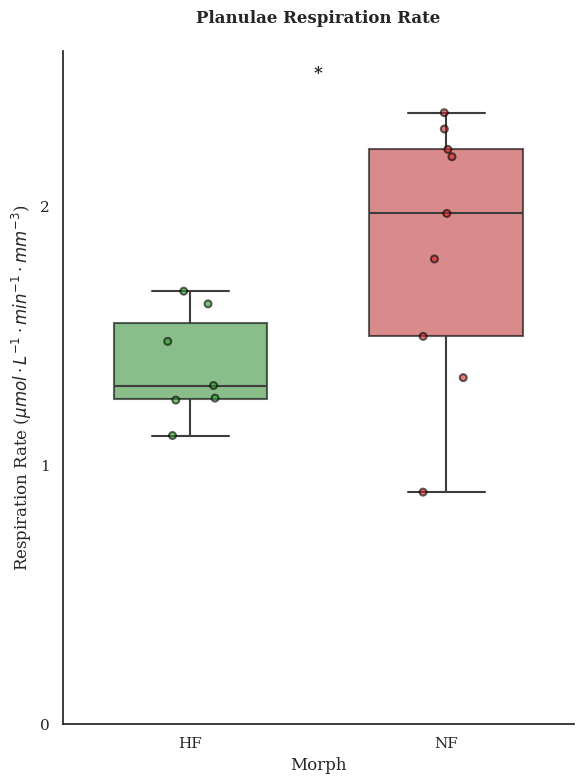

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Perform Independent T-test since both groups are normal
stat_final, p_val_final = stats.ttest_ind(hf_final_vals, nf_final_vals)

print(f"--- FINAL STATISTICAL RESULT ---")
print(f"Test: Independent T-test")
print(f"p-value: {p_val_final:.4f}")

# 2. Plotting with Global Styles
plt.figure(figsize=global_fig_size)

# Boxplot
ax = sns.boxplot(
    data=df_resp_final,
    x='Morph',
    y='Respiration_Rate_per_mm3',
    palette=variant_colors,
    hue='Morph',
    width=global_box_width,
    showfliers=False,
    linewidth=global_line_width,
    legend=False,
    boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}
)

# Stripplot
sns.stripplot(
    data=df_resp_final,
    x='Morph',
    y='Respiration_Rate_per_mm3',
    hue='Morph',
    palette=variant_colors,
    size=global_marker_size,
    jitter=global_jitter,
    alpha=global_alpha,
    zorder=5,
    legend=False,
    edgecolor=global_edgecolor,
    linewidth=global_line_width
)

# Significance Label
sig_label = get_significance_label(p_val_final)
y_max = df_resp_final['Respiration_Rate_per_mm3'].max()
plt.text(0.5, y_max * 1.05,
         sig_label,
         ha='center', va='bottom',
         fontsize=global_asterisk_size,
         fontweight=global_asterisk_weight)

# Final Touches
plt.title("Planulae Respiration Rate", fontweight="bold")
# Corrected LaTeX label: single backslash inside a raw string for Matplotlib math
plt.ylabel(r"Respiration Rate ($\mu mol \cdot L^{-1} \cdot min^{-1} \cdot mm^{-3}$)")
plt.xlabel("Morph")
ax.yaxis.set_major_locator(plt.MaxNLocator(global_y_nbins))
plt.ylim(0, 2.6)
sns.despine()
plt.tight_layout()
#plt.savefig("Respiration_Rate_Final_Cleaned.png", dpi=600)
plt.show()

# Larval Protein Density

## Block 1: Load Protein Data & Merge with Volume
We will load the protein concentration data ($μg/ml$) and associate it with the average morph volumes calculated in the previous 'Planulae Volume' section.

In [21]:
import pandas as pd

# 1. Load protein data
df_prot = pd.read_csv('Prot_16042026.csv', encoding='latin1')

# 2. Cleanup: Strip whitespace and drop empty rows
df_prot.columns = df_prot.columns.str.strip()
print(f"Detected columns: {df_prot.columns.tolist()}")

df_prot = df_prot.dropna(subset=['morph']).copy()
df_prot['morph'] = df_prot['morph'].str.strip()

# --- Show number of samples loaded ---
print(f"Total valid samples loaded: {len(df_prot)}")
print(df_prot.groupby('morph').size())

# 3. Map average volumes from the Planulae Volume section
df_prot['Avg_Volume_mm3'] = df_prot['morph'].map(avg_volume)

# 4. Recalculate protein density using absolute protein per larva divided by individual morph volume
# FIX: Using 'con per planulae ug/ml' which is the correct column in your CSV
df_prot['Protein_Density_ug_mm3'] = df_prot['con per planulae ug/ml'] / df_prot['Avg_Volume_mm3']

print("\n--- Average Volumes Used for Calculation (mm3) ---")
display(avg_volume)

print("\n--- PROTEIN DATA PREVIEW ---")
display(df_prot[['sample id', 'morph', 'con per planulae ug/ml', 'Protein_Density_ug_mm3']].head())

print("\n--- PROTEIN DENSITY SUMMARY (Initial) ---")
prot_summary = df_prot.groupby('morph')['Protein_Density_ug_mm3'].agg(['count', 'mean', 'std'])
display(prot_summary)

Detected columns: ['sample id', 'morph', 'OD1', 'OD2', 'OD3', 'ave OD', 'ug/ml', 'no of planulae', 'con per planulae ug/ml', 'avarage vol', 'prot ug/mm3']
Total valid samples loaded: 19
morph
HF    10
NF     9
dtype: int64

--- Average Volumes Used for Calculation (mm3) ---


,Volume mm³
morph,
HF,0.302380
NF,0.269826



--- PROTEIN DATA PREVIEW ---


,sample id,morph,con per planulae ug/ml,Protein_Density_ug_mm3
0,600,HF,21.146986,69.935021
1,601,HF,14.164119,46.842042
2,602,HF,14.180176,46.895141
3,603,HF,20.076215,66.393885
4,604,HF,19.770413,65.382568



--- PROTEIN DENSITY SUMMARY (Initial) ---


,count,mean,std
morph,,,
HF,10,64.609425,10.375863
NF,9,61.611067,10.939784


## Block 2: Outlier Removal
Applying the 1.5 IQR method to ensure the protein density comparison is robust.

In [22]:
# --- BLOCK 2: UPDATED OUTLIER REMOVAL ---
def remove_prot_outliers(df, group_col, val_col):
    clean_list = []
    outlier_list = []
    print("--- OUTLIER CALCULATION LOGIC (1.5 IQR Rule) ---")

    df_subset = df.dropna(subset=[val_col, group_col])
    for name, group in df_subset.groupby(group_col):
        Q1 = group[val_col].quantile(0.25)
        Q3 = group[val_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR

        print(f"\nMorph: {name}")
        print(f"  - Lower Fence: {lower_fence:.2f}, Upper Fence: {upper_fence:.2f}")

        clean = group[(group[val_col] >= lower_fence) & (group[val_col] <= upper_fence)]
        outliers = group[(group[val_col] < lower_fence) | (group[val_col] > upper_fence)]

        clean_list.append(clean)
        outlier_list.append(outliers)

    return pd.concat(clean_list), pd.concat(outlier_list)

df_prot_clean, df_prot_removed = remove_prot_outliers(df_prot, 'morph', 'Protein_Density_ug_mm3')

# --- Formatting: Use 'sample id' instead of missing 'vile no' ---
df_prot_clean['sample id'] = df_prot_clean['sample id'].astype(int)
df_prot_clean = df_prot_clean.sort_values('sample id').set_index('sample id', drop=False)

if not df_prot_removed.empty:
    df_prot_removed['sample id'] = df_prot_removed['sample id'].astype(int)
    df_prot_removed = df_prot_removed.sort_values('sample id').set_index('sample id', drop=False)

print("\n--- PROTEIN OUTLIER SUMMARY ---")
print(f"Samples remaining: {len(df_prot_clean)}")
if not df_prot_removed.empty:
    # Using 'con per planulae ug/ml' to match your actual column names
    display(df_prot_removed[['sample id', 'morph', 'con per planulae ug/ml', 'Protein_Density_ug_mm3']])

print("\n--- FULL CLEANED DATAFRAME ---")
display(df_prot_clean[['sample id', 'morph', 'con per planulae ug/ml', 'Protein_Density_ug_mm3']])

--- OUTLIER CALCULATION LOGIC (1.5 IQR Rule) ---

Morph: HF
  - Lower Fence: 50.40, Upper Fence: 81.53

Morph: NF
  - Lower Fence: 37.81, Upper Fence: 90.73

--- PROTEIN OUTLIER SUMMARY ---
Samples remaining: 17


,sample id,morph,con per planulae ug/ml,Protein_Density_ug_mm3
sample id,,,,
601,601,HF,14.164119,46.842042
602,602,HF,14.180176,46.895141



--- FULL CLEANED DATAFRAME ---


,sample id,morph,con per planulae ug/ml,Protein_Density_ug_mm3
sample id,,,,
600,600,HF,21.146986,69.935021
603,603,HF,20.076215,66.393885
604,604,HF,19.770413,65.382568
605,605,HF,20.681355,68.395136
606,606,HF,22.580929,74.677203
607,607,HF,18.435882,60.969151
608,608,HF,23.281058,76.992593
609,609,HF,21.049162,69.611509
610,610,NF,19.590543,72.604470


## Block 3: Normality Check
We evaluate the distribution of the cleaned protein density data for both HF and NF groups to determine the appropriate statistical test.

In [23]:
# --- BLOCK 3: UPDATED NORMALITY TEST ---
hf_prot = df_prot_clean[df_prot_clean['morph'] == 'HF']['Protein_Density_ug_mm3']
nf_prot = df_prot_clean[df_prot_clean['morph'] == 'NF']['Protein_Density_ug_mm3']

stat_hf, p_hf = stats.shapiro(hf_prot)
stat_nf, p_nf = stats.shapiro(nf_prot)

print(f"--- PROTEIN DENSITY NORMALITY TEST (Corrected Logic) ---")
print(f"HF Morph (n={len(hf_prot)}): p = {p_hf:.4f}")
print(f"NF Morph (n={len(nf_prot)}): p = {p_nf:.4f}")

--- PROTEIN DENSITY NORMALITY TEST (Corrected Logic) ---
HF Morph (n=8): p = 0.9339
NF Morph (n=9): p = 0.3551


## Block 4: Statistical Comparison & Visualization
Based on the normality results, we perform the final comparison and generate the figure.


Selected Test: Independent T-test, p = 0.0996


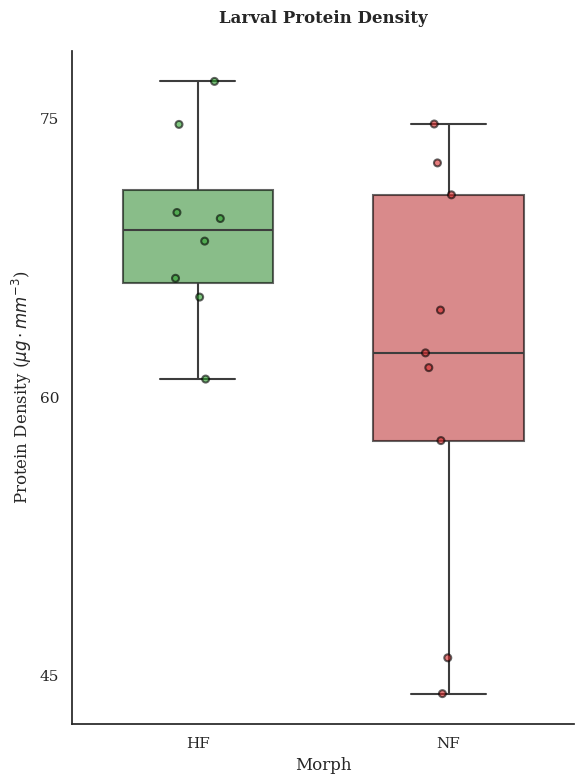

In [24]:
# --- BLOCK 4: UPDATED STATS & PLOTTING ---
# Ensure variables are defined in case cell b2e83dab was skipped
hf_prot = df_prot_clean[df_prot_clean['morph'] == 'HF']['Protein_Density_ug_mm3']
nf_prot = df_prot_clean[df_prot_clean['morph'] == 'NF']['Protein_Density_ug_mm3']

if p_hf > 0.05 and p_nf > 0.05:
    test_name = "Independent T-test"
    stat, p_val = stats.ttest_ind(hf_prot, nf_prot)
else:
    test_name = "Mann-Whitney U"
    stat, p_val = stats.mannwhitneyu(hf_prot, nf_prot)

print(f"\nSelected Test: {test_name}, p = {p_val:.4f}")

plt.figure(figsize=global_fig_size)

# Set explicit order to put HF on the left
plot_order = ['HF', 'NF']

# Boxplot
ax = sns.boxplot(
    data=df_prot_clean,
    x='morph',
    y='Protein_Density_ug_mm3',
    order=plot_order,
    palette=variant_colors,
    hue='morph',
    width=global_box_width,
    showfliers=False,
    linewidth=global_line_width,
    legend=False,
    boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}
)

# Stripplot
sns.stripplot(
    data=df_prot_clean,
    x='morph',
    y='Protein_Density_ug_mm3',
    order=plot_order,
    hue='morph',
    palette=variant_colors,
    size=global_marker_size,
    jitter=global_jitter,
    alpha=global_alpha,
    zorder=5,
    legend=False,
    edgecolor=global_edgecolor,
    linewidth=global_line_width
)

# Dynamic Significance Marker - Modified to hide 'n.s.'
sig_label = get_significance_label(p_val)
if sig_label != 'n.s.':
    y_max = df_prot_clean['Protein_Density_ug_mm3'].max()
    plt.text(0.5, y_max * 1.05, sig_label, ha='center', va='bottom', fontsize=global_asterisk_size, fontweight=global_asterisk_weight)

plt.title("Larval Protein Density", fontweight="bold")
plt.ylabel(r"Protein Density ($\mu g \cdot mm^{-3}$)")
plt.xlabel("Morph")
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(global_y_nbins))
sns.despine()
plt.tight_layout()
plt.savefig("Larval_Protein_Density_Corrected.png", dpi=600)
plt.show()

# Symbionts Cell Count

## Block 1&2: Load Data & Convert Metrics (Cell/Planula + Cell/Volume)
This block loads the CSV, handles the spelling of your columns, and performs the mathematical normalizations. Note: I added an EXTRACTION_VOL_ML variable. If you crushed your planulae in 1 mL of seawater/preservative, leave it as 1.0. If you used 500 µL, change it to 0.5.

In [25]:
# 2. Load Data
filename = 'Algae_cell_count_16042026.csv'
df = pd.read_csv(filename)
df.columns = df.columns.str.strip() # Clean hidden spaces

# 2.5 Convert to cell/planula & cell/volume
EXTRACTION_VOL_ML = 1.0 # Change this if your slurry volume was not 1 mL

# Calculate Total Cells per Planula
# Formula: (Concentration per mL * Extraction Volume) / Number of Planulae in vial
df['Cells_per_Planula'] = (df['Conc (Cells/mL)'] * EXTRACTION_VOL_ML) / df['no of plaunlae per vile']

# Assign Morphotype Volumes
volume_map = {'HF': 0.3024, 'NF': 0.2698}
df['Volume_mm3'] = df['morph'].map(volume_map)

# Calculate Cell Density (Cells per mm³)
df['Cells_per_mm3'] = df['Cells_per_Planula'] / df['Volume_mm3']

# Drop any rows with missing calculations
df = df.dropna(subset=['Cells_per_mm3'])
print(f"✅ Data loaded and converted. Total viable samples: {len(df)}")

✅ Data loaded and converted. Total viable samples: 19


In [26]:
# Block 2.5: Internal Count Divergence Check (Per Sample)
print("--- RAW COUNT DIVERGENCE ANALYSIS (PER SAMPLE) ---")

# 1. Locate where the raw grid counts start in your CSV
# Based on your file, it starts at the column named 'Counts...'
counts_start_col = df.columns.get_loc('Counts...')

# 2. Extract just the grid counts for each row, ignoring empty columns
count_data = df.iloc[:, counts_start_col:].apply(pd.to_numeric, errors='coerce')

# 3. Calculate Mean, Standard Deviation, and CV% across the columns (axis=1) for each sample
df['Grid_Mean'] = count_data.mean(axis=1)
df['Grid_Std'] = count_data.std(axis=1)
df['Grid_CV(%)'] = (df['Grid_Std'] / df['Grid_Mean']) * 100

# Create a clean summary table
divergence_df = df[['Sample No', 'morph', 'Grid_Mean', 'Grid_Std', 'Grid_CV(%)']].copy()

# 4. Automated Warning System for Bad Samples
high_divergence = divergence_df[divergence_df['Grid_CV(%)'] > 30]

if not high_divergence.empty:
    print(f"⚠️ WARNING: Found {len(high_divergence)} sample(s) with highly divergent internal counts (CV > 30%).")
    print("This indicates severe algae clumping, debris, or poor homogenization in these specific vials:\n")
    print(high_divergence.round(2).to_string(index=False))
    print("\n-> This strongly justifies using the IQR Outlier removal in Block 3.")
else:
    print("✅ All samples show excellent internal counting consistency (CV < 30%).\n")

print("-" * 60)



--- RAW COUNT DIVERGENCE ANALYSIS (PER SAMPLE) ---
⚠️ WARNING: Found 19 sample(s) with highly divergent internal counts (CV > 30%).
This indicates severe algae clumping, debris, or poor homogenization in these specific vials:

 Sample No morph  Grid_Mean  Grid_Std  Grid_CV(%)
       600    HF  144601.53 292337.62      202.17
       601    HF    6923.10  13994.49      202.14
       602    HF   97992.89 213316.93      217.69
       603    HF   16156.46  35160.15      217.62
       604    HF    5384.89  11720.36      217.65
       605    HF   10106.81  23452.21      232.04
       606    HF   65660.65 161254.55      245.59
       607    HF   26596.81  61716.37      232.04
       608    HF    8324.77  21511.11      258.40
       609    HF    9840.84  22835.05      232.04
       610    NF   27910.85  69928.60      250.54
       611    NF   68589.34 162405.18      236.78
       612    NF   23365.91  61565.58      263.48
       613    NF   12107.72  30329.67      250.50
       614    NF   7966

In [27]:
# --- TIER 1: TECHNICAL OUTLIER REMOVAL (PER SAMPLE) ---
print("--- TIER 1: TECHNICAL QC REPORT (GRID CLUMPING) ---")
counts_start_col = df.columns.get_loc('Counts...')
count_data = df.iloc[:, counts_start_col:]

clean_means = []
grids_dropped = []

# Iterate through every sample (row)
for idx, row in count_data.iterrows():
    # Extract only valid numbers, drop empty columns
    grids = pd.to_numeric(row, errors='coerce').dropna()

    # If a sample has at least 4 grid counts, we can perform IQR
    if len(grids) >= 4:
        Q1 = np.percentile(grids, 25)
        Q3 = np.percentile(grids, 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Filter the grids for this specific sample
        clean_grids = grids[(grids >= lower) & (grids <= upper)]
        clean_means.append(clean_grids.mean())
        grids_dropped.append(len(grids) - len(clean_grids))
    else:
        # Not enough grids to do IQR reliably, just take the mean
        clean_means.append(grids.mean())
        grids_dropped.append(0)

df['Clean_Grid_Mean'] = clean_means
df['Clumps_Dropped'] = grids_dropped

print(f"Total Technical Clumps (Grids) Dropped across all samples: {sum(grids_dropped)}")
# Show samples where grids were heavily manipulated
highly_cleaned = df[df['Clumps_Dropped'] > 0]
if not highly_cleaned.empty:
    print("\nSamples requiring grid cleanup:")
    print(highly_cleaned[['Sample No', 'morph', 'Average', 'Clean_Grid_Mean', 'Clumps_Dropped']])

--- TIER 1: TECHNICAL QC REPORT (GRID CLUMPING) ---
Total Technical Clumps (Grids) Dropped across all samples: 30

Samples requiring grid cleanup:
    Sample No morph  Average  Clean_Grid_Mean  Clumps_Dropped
0         600    HF  23.5000     74692.846108               1
1         601    HF   2.2500      3597.670365               1
2         602    HF  18.2000     49361.881511               1
3         603    HF   9.0000      8157.952863               1
4         604    HF   2.0000      2733.320483               1
5         605    HF   6.3333      4994.588714               1
6         606    HF  45.7143     31655.170585               1
7         607    HF  16.6667     13109.189189               1
8         608    HF   6.3750       784.951906               3
9         609    HF   6.1667      4863.708081               1
10        610    NF  11.8571      7957.306774               2
11        611    NF  39.3333     32961.698353               1
12        612    NF  16.3750      2160.059963  

In [28]:
# --- RECALCULATE DENSITIES BASED ON CLEAN MEANS ---
# Standard Hemocytometer formula: Count x 10,000
df['Clean_Conc_Cells_mL'] = df['Clean_Grid_Mean'] * 10000

EXTRACTION_VOL_ML = 1.0 # Adjust if you didn't use 1 mL
df['Cells_per_Planula'] = (df['Clean_Conc_Cells_mL'] * EXTRACTION_VOL_ML) / df['no of plaunlae per vile']

volume_map = {'HF': 0.3024, 'NF': 0.2698}
df['Volume_mm3'] = df['morph'].map(volume_map)
df['Cells_per_mm3'] = df['Cells_per_Planula'] / df['Volume_mm3']

df = df.dropna(subset=['Cells_per_mm3'])

# --- TIER 2: BIOLOGICAL OUTLIER REMOVAL (PER MORPH) ---
print("\n--- TIER 2: BIOLOGICAL QC REPORT (POPULATION DENSITY) ---")
def remove_biological_outliers(data, group_col, val_col):
    outliers_list, clean_list = [], []
    for name, group in data.groupby(group_col):
        Q1, Q3 = group[val_col].quantile(0.25), group[val_col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

        outliers = group[(group[val_col] < lower) | (group[val_col] > upper)]
        clean = group[(group[val_col] >= lower) & (group[val_col] <= upper)]

        outliers_list.append(outliers)
        clean_list.append(clean)
    return pd.concat(clean_list), pd.concat(outliers_list)

df_clean, df_outliers = remove_biological_outliers(df, 'morph', 'Cells_per_mm3')

print(f"Total Biological Outliers Removed: {len(df_outliers)}")
if not df_outliers.empty:
    print(df_outliers[['Sample No', 'morph', 'Cells_per_mm3']])
print(f"Total Samples Remaining for Final Stats: {len(df_clean)}")


--- TIER 2: BIOLOGICAL QC REPORT (POPULATION DENSITY) ---
Total Biological Outliers Removed: 3
    Sample No morph  Cells_per_mm3
0         600    HF   2.470002e+09
2         602    HF   1.632337e+09
11        611    NF   4.072362e+08
Total Samples Remaining for Final Stats: 16


## Block 4 & 5: Normality Check & Automated Stats
This block evaluates both metrics (Cells_per_Planula and Cells_per_mm3), decides between a T-test or Mann-Whitney U based on normality, and prints a formatted statistical report.

In [29]:
# 4. Normality Test & 5. Auto Statistical Test
metrics_to_test = ['Cells_per_Planula', 'Cells_per_mm3']
morphs = df_clean['morph'].unique()

print("\n" + "="*45)
print(" 🔬 COMPREHENSIVE STATISTICAL REPORT ")
print("="*45)

for metric in metrics_to_test:
    print(f"\n➤ Analyzing: {metric}")
    print("-" * 45)

    normality_pass = True
    groups = []

    # Check Normality
    for morph in morphs:
        data = df_clean[df_clean['morph'] == morph][metric].dropna()
        groups.append(data)
        stat, p_shapiro = stats.shapiro(data)
        is_normal = p_shapiro > 0.05
        normality_pass = normality_pass and is_normal
        print(f"[{morph}] Normality (p={p_shapiro:.4f}) -> {'Normal ✅' if is_normal else 'NOT Normal ❌'}")

    # Run Automated Stats
    if len(groups) == 2:
        if normality_pass:
            stat, p_val = stats.ttest_ind(groups[0], groups[1])
            test_used = "Independent T-test"
        else:
            stat, p_val = stats.mannwhitneyu(groups[0], groups[1])
            test_used = "Mann-Whitney U Test"

        sig = "Significant ⭐" if p_val < 0.05 else "Not Significant (ns)"

        print(f"Test Used : {test_used}")
        print(f"P-Value   : {p_val:.5e} | {sig}")
        print(f"Mean HF   : {groups[0].mean():.2f}")
        print(f"Mean NF   : {groups[1].mean():.2f}")
print("="*45)


 🔬 COMPREHENSIVE STATISTICAL REPORT 

➤ Analyzing: Cells_per_Planula
---------------------------------------------
[HF] Normality (p=0.0052) -> NOT Normal ❌
[NF] Normality (p=0.3801) -> Normal ✅
Test Used : Mann-Whitney U Test
P-Value   : 8.78477e-01 | Not Significant (ns)
Mean HF   : 30442519.84
Mean NF   : 22757506.32

➤ Analyzing: Cells_per_mm3
---------------------------------------------
[HF] Normality (p=0.0052) -> NOT Normal ❌
[NF] Normality (p=0.3801) -> Normal ✅
Test Used : Mann-Whitney U Test
P-Value   : 8.78477e-01 | Not Significant (ns)
Mean HF   : 100669708.46
Mean NF   : 84349541.58


## Plotting

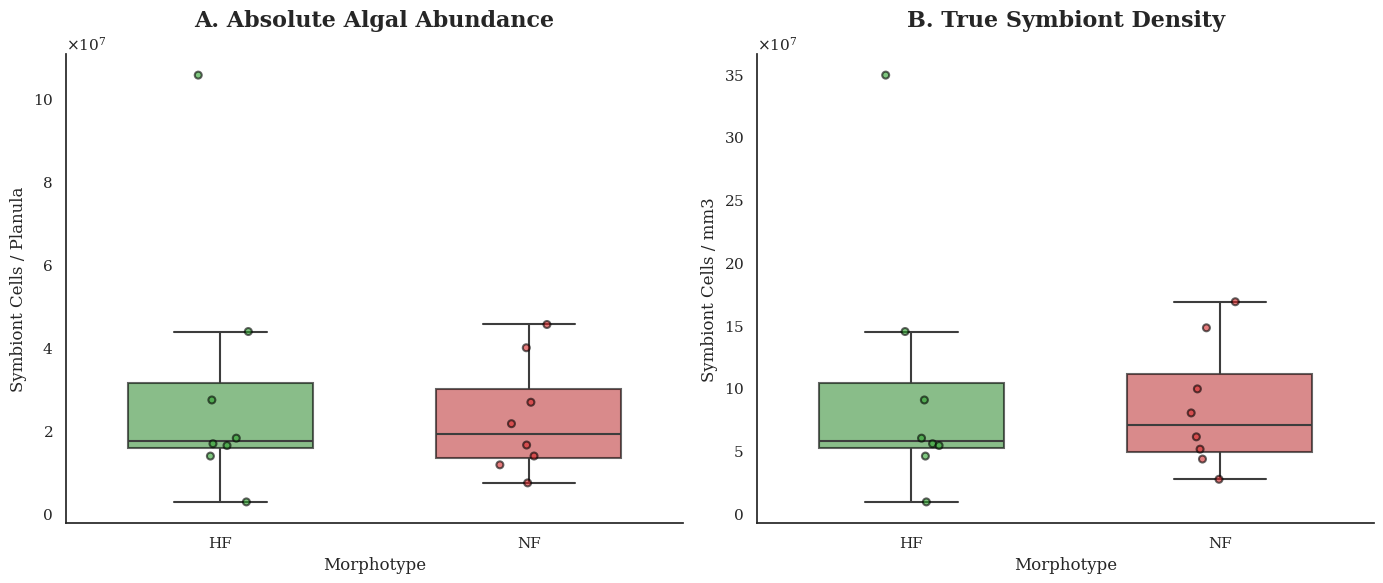

--- Descriptive Statistics ---


morph                              HF            NF
Cells_per_Planula count  8.000000e+00  8.000000e+00
                  mean   3.044252e+07  2.275751e+07
                  std    3.257092e+07  1.368155e+07
                  min    2.616506e+06  7.200200e+06
                  25%    1.557592e+07  1.314768e+07
                  50%    1.731849e+07  1.890258e+07
                  75%    3.131921e+07  2.992997e+07
                  max    1.055172e+08  4.539109e+07
Cells_per_mm3     count  8.000000e+00  8.000000e+00
                  mean   1.006697e+08  8.434954e+07
                  std    1.077081e+08  5.070996e+07
                  min    8.652468e+06  2.668718e+07
                  25%    5.150767e+07  4.873120e+07
                  50%    5.727014e+07  7.006146e+07
                  75%    1.035688e+08  1.109339e+08
                  max    3.489327e+08  1.682398e+08

In [30]:
# 6. Final Plotting (Normalized Y-Axis with Global Styling)
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_df = df_clean.copy()

# Panel A: Cells per Planula (Absolute)
sns.boxplot(data=plot_df, x='morph', y='Cells_per_Planula', hue='morph', palette=variant_colors,
            ax=axes[0], showfliers=False, width=global_box_width,
            linewidth=global_line_width, boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}, legend=False)
sns.stripplot(data=plot_df, x='morph', y='Cells_per_Planula', hue='morph', palette=variant_colors,
              alpha=global_alpha, jitter=global_jitter, size=global_marker_size,
              ax=axes[0], edgecolor=global_edgecolor, linewidth=global_line_width, legend=False)

axes[0].set_title("A. Absolute Algal Abundance", fontsize=16, weight='bold')
axes[0].set_ylabel("Symbiont Cells / Planula")
axes[0].set_xlabel("Morphotype")

# Format Y-axis to 10^7 using global scaling preferences
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((7, 7))
axes[0].yaxis.set_major_formatter(formatter)

# Panel B: Cells per mm3 (Density)
sns.boxplot(data=plot_df, x='morph', y='Cells_per_mm3', hue='morph', palette=variant_colors,
            ax=axes[1], showfliers=False, width=global_box_width,
            linewidth=global_line_width, boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}, legend=False)
sns.stripplot(data=plot_df, x='morph', y='Cells_per_mm3', hue='morph', palette=variant_colors,
              alpha=global_alpha, jitter=global_jitter, size=global_marker_size,
              ax=axes[1], edgecolor=global_edgecolor, linewidth=global_line_width, legend=False)

axes[1].set_title("B. True Symbiont Density", fontsize=16, weight='bold')
axes[1].set_ylabel("Symbiont Cells / mm3")
axes[1].set_xlabel("Morphotype")

# Format Y-axis to 10^7
axes[1].yaxis.set_major_formatter(formatter)

sns.despine(trim=False)
plt.tight_layout()
#plt.savefig("Symbiont_Counts_Final.png", dpi=600)
plt.show()

# Descriptive Statistics
print("--- Descriptive Statistics ---")
stats_summary = plot_df.groupby('morph')[['Cells_per_Planula', 'Cells_per_mm3']].describe().T
display(stats_summary.round(2))

### 2x3 Integrated Summary Panel
This panel regenerates all six analyses directly into a single figure for maximum quality and the requested layout.

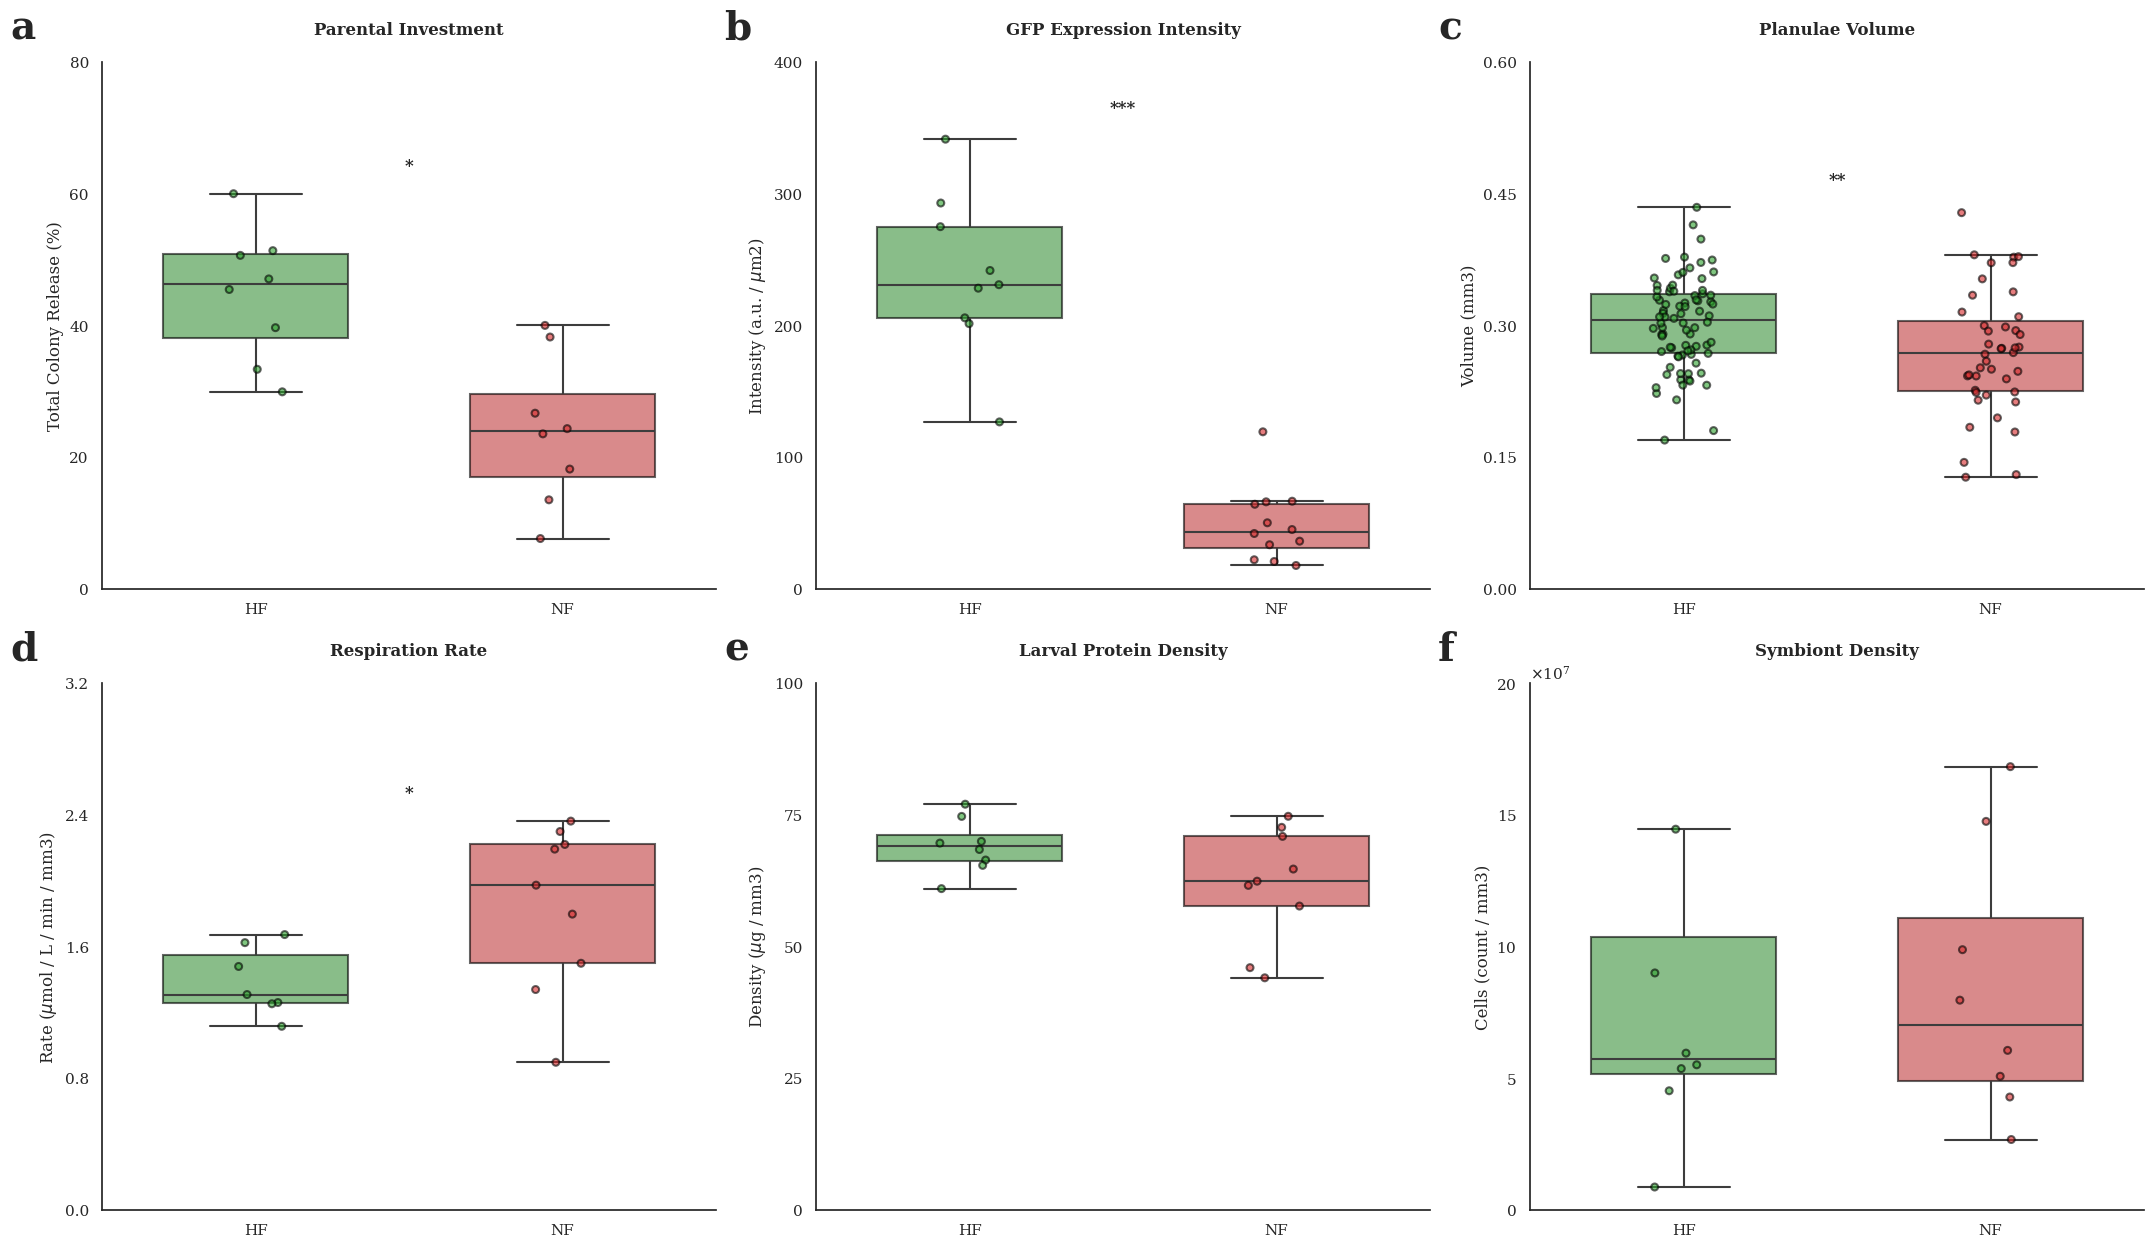

In [31]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize a 3-column, 2-row figure (3x2 layout)
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

# Helper for adding asterisks based on previously calculated p-values
def annotate_sig(ax, p, data_y):
    label = get_significance_label(p)
    if label != 'n.s.':
        y_pos = data_y.max() * 1.05
        ax.text(0.5, y_pos, label, ha='center', va='bottom', fontsize=global_asterisk_size, fontweight=global_asterisk_weight)

# Helper for panel labeling
def label_panel(ax, letter):
    ax.text(-0.15, 1.1, letter, transform=ax.transAxes, fontsize=28, fontweight='bold', va='top', ha='left')

# --- PANEL a: Release Pattern ---
sns.boxplot(data=df_filtered, x='morph', y='% from total coloney', palette=variant_colors, hue='morph', width=global_box_width, showfliers=False, linewidth=global_line_width, ax=axes[0], boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}, legend=False)
sns.stripplot(data=df_filtered, x='morph', y='% from total coloney', hue='morph', palette=variant_colors, size=global_marker_size, jitter=global_jitter, alpha=global_alpha, zorder=5, ax=axes[0], edgecolor=global_edgecolor, linewidth=global_line_width, legend=False)
axes[0].set_title("Parental Investment", fontweight='bold')
axes[0].set_ylabel("Total Colony Release (%)")
axes[0].set_ylim(0, 80)
axes[0].yaxis.set_major_locator(ticker.LinearLocator(numticks=5))
annotate_sig(axes[0], 0.0156, df_filtered['% from total coloney'])
label_panel(axes[0], "a")

# --- PANEL b: GFP Intensity ---
sns.boxplot(data=df_gfp, x='Variant', y='Intensity_per_µm2', palette=variant_colors, hue='Variant', width=global_box_width, showfliers=False, linewidth=global_line_width, ax=axes[1], boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}, legend=False)
sns.stripplot(data=df_gfp, x='Variant', y='Intensity_per_µm2', hue='Variant', palette=variant_colors, size=global_marker_size, jitter=global_jitter, alpha=global_alpha, zorder=5, ax=axes[1], edgecolor=global_edgecolor, linewidth=global_line_width, legend=False)
axes[1].set_title("GFP Expression Intensity", fontweight='bold')
axes[1].set_ylabel(r"Intensity (a.u. / $\mu$m2)")
axes[1].set_ylim(0, 400)
axes[1].yaxis.set_major_locator(ticker.LinearLocator(numticks=5))
annotate_sig(axes[1], 1.1467e-08, df_gfp['Intensity_per_µm2'])
label_panel(axes[1], "b")

# --- PANEL c: Planulae Volume ---
sns.boxplot(data=df26_clean, x='morph', y='Volume mm³', palette=variant_colors, hue='morph', width=global_box_width, showfliers=False, linewidth=global_line_width, ax=axes[2], boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}, legend=False)
sns.stripplot(data=df26_clean, x='morph', y='Volume mm³', hue='morph', palette=variant_colors, size=global_marker_size, jitter=global_jitter, alpha=global_alpha, zorder=5, ax=axes[2], edgecolor=global_edgecolor, linewidth=global_line_width, legend=False)
axes[2].set_title("Planulae Volume", fontweight='bold')
axes[2].set_ylabel("Volume (mm3)")
axes[2].set_ylim(0, 0.6)
axes[2].yaxis.set_major_locator(ticker.LinearLocator(numticks=5))
annotate_sig(axes[2], 3.21720e-03, df26_clean['Volume mm³'])
label_panel(axes[2], "c")

# --- PANEL d: Respiration Rate ---
sns.boxplot(data=df_resp_final, x='Morph', y='Respiration_Rate_per_mm3', palette=variant_colors, hue='Morph', width=global_box_width, showfliers=False, linewidth=global_line_width, ax=axes[3], boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}, legend=False)
sns.stripplot(data=df_resp_final, x='Morph', y='Respiration_Rate_per_mm3', hue='Morph', palette=variant_colors, size=global_marker_size, jitter=global_jitter, alpha=global_alpha, zorder=5, ax=axes[3], edgecolor=global_edgecolor, linewidth=global_line_width, legend=False)
axes[3].set_title("Respiration Rate", fontweight='bold')
axes[3].set_ylabel(r"Rate ($\mu$mol / L / min / mm3)")
axes[3].set_ylim(0, 3.2)
axes[3].yaxis.set_major_locator(ticker.LinearLocator(numticks=5))
annotate_sig(axes[3], 0.0426, df_resp_final['Respiration_Rate_per_mm3'])
label_panel(axes[3], "d")

# --- PANEL e: Protein Density ---
sns.boxplot(data=df_prot_clean, x='morph', y='Protein_Density_ug_mm3', palette=variant_colors, hue='morph', width=global_box_width, showfliers=False, linewidth=global_line_width, ax=axes[4], boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}, legend=False)
sns.stripplot(data=df_prot_clean, x='morph', y='Protein_Density_ug_mm3', hue='morph', palette=variant_colors, size=global_marker_size, jitter=global_jitter, alpha=global_alpha, zorder=5, ax=axes[4], edgecolor=global_edgecolor, linewidth=global_line_width, legend=False)
axes[4].set_title("Larval Protein Density", fontweight='bold')
axes[4].set_ylabel(r"Density ($\mu$g / mm3)")
axes[4].set_ylim(0, 100)
axes[4].yaxis.set_major_locator(ticker.LinearLocator(numticks=5))
annotate_sig(axes[4], 0.0996, df_prot_clean['Protein_Density_ug_mm3'])
label_panel(axes[4], "e")

# --- PANEL f: Symbiont Density ---
sns.boxplot(data=df_clean, x='morph', y='Cells_per_mm3', palette=variant_colors, hue='morph', width=global_box_width, showfliers=False, linewidth=global_line_width, ax=axes[5], boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}, legend=False)
sns.stripplot(data=df_clean, x='morph', y='Cells_per_mm3', hue='morph', palette=variant_colors, size=global_marker_size, jitter=global_jitter, alpha=global_alpha, zorder=5, ax=axes[5], edgecolor=global_edgecolor, linewidth=global_line_width, legend=False)
axes[5].set_title("Symbiont Density", fontweight='bold')
axes[5].set_ylabel(r"Cells (count / mm3)")

# Science notation logic for Panel F
formatter_f = ticker.ScalarFormatter(useMathText=True)
formatter_f.set_scientific(True)
formatter_f.set_powerlimits((7, 7))
axes[5].yaxis.set_major_formatter(formatter_f)
axes[5].set_ylim(0, 2.0e8)
axes[5].yaxis.set_major_locator(ticker.LinearLocator(numticks=5))

annotate_sig(axes[5], 0.87, df_clean['Cells_per_mm3'])
label_panel(axes[5], "f")

for ax in axes:
    ax.set_xlabel("")
    sns.despine(ax=ax)

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.savefig("Larval_Baseline_Physiology.png", dpi=600)
plt.savefig("Larval_Baseline_Physiology.tiff", dpi=600)
plt.show()

In [32]:
import pandas as pd

# Helper to calculate stats per group
def get_stats(df, group_col, val_col, morphs=['HF', 'NF']):
    stats_dict = {}
    for m in morphs:
        data = df[df[group_col] == m][val_col]
        stats_dict[f'{m}_Mean'] = data.mean()
        stats_dict[f'{m}_SD'] = data.std()
        stats_dict[f'{m}_N'] = data.count()
    return stats_dict

# Compile results into a list
summary_data = []

# 1. Parental Investment (%)
p_a = 0.0156
stats_a = get_stats(df_filtered, 'morph', '% from total coloney')
summary_data.append({'Panel': 'a', 'Metric': 'Parental Investment (%)', **stats_a, 'p-value': p_a})

# 2. GFP Intensity
p_b = 1.1467e-08
stats_b = get_stats(df_gfp, 'Variant', 'Intensity_per_µm2')
summary_data.append({'Panel': 'b', 'Metric': 'GFP Intensity', **stats_b, 'p-value': p_b})

# 3. Planulae Volume
p_c = 3.21720e-03
stats_c = get_stats(df26_clean, 'morph', 'Volume mm³')
summary_data.append({'Panel': 'c', 'Metric': 'Volume (mm3)', **stats_c, 'p-value': p_c})

# 4. Respiration Rate
p_d = 0.0426
stats_d = get_stats(df_resp_final, 'Morph', 'Respiration_Rate_per_mm3')
summary_data.append({'Panel': 'd', 'Metric': 'Respiration Rate', **stats_d, 'p-value': p_d})

# 5. Protein Density
p_e = 0.0996
stats_e = get_stats(df_prot_clean, 'morph', 'Protein_Density_ug_mm3')
summary_data.append({'Panel': 'e', 'Metric': 'Protein Density', **stats_e, 'p-value': p_e})

# 6. Symbiont Density
p_f = 0.8785 # From Mann-Whitney U test result
stats_f = get_stats(df_clean, 'morph', 'Cells_per_mm3')
summary_data.append({'Panel': 'f', 'Metric': 'Symbiont Density', **stats_f, 'p-value': p_f})

# Create DataFrame
full_stats_df = pd.DataFrame(summary_data)

# Display the table
print("Full Statistical Summary for Integrated Panels")
display(full_stats_df.round(4))

Full Statistical Summary for Integrated Panels


,Panel,Metric,HF_Mean,HF_SD,HF_N,NF_Mean,NF_SD,NF_N,p-value
0,a,Parental Investment (%),4.467530e+01,9.949800e+00,8,2.401070e+01,1.119790e+01,8,0.0156
1,b,GFP Intensity,2.382205e+02,6.123590e+01,9,4.860320e+01,2.817030e+01,12,0.0000
2,c,Volume (mm3),3.024000e-01,5.050000e-02,82,2.698000e-01,6.910000e-02,43,0.0032
3,d,Respiration Rate,1.386500e+00,2.083000e-01,7,1.841000e+00,5.034000e-01,9,0.0426
4,e,Protein Density,6.904460e+01,5.100200e+00,8,6.161110e+01,1.093980e+01,9,0.0996
5,f,Symbiont Density,1.006697e+08,1.077081e+08,8,8.434954e+07,5.070996e+07,8,0.8785


In [33]:
import sys
import pandas
import numpy
import matplotlib
import seaborn
import scipy

# Specifically check versions of libraries used in the notebook
used_libs = {
    "pandas": pandas.__version__,
    "numpy": numpy.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": seaborn.__version__,
    "scipy": scipy.__version__,
    "python": sys.version
}

print("--- Versions of libraries used in this notebook ---")
for lib, version in used_libs.items():
    print(f"{lib}: {version}")

print("\n--- Full environment package list ---")


--- Versions of libraries used in this notebook ---
pandas: 2.2.2
numpy: 2.0.2
matplotlib: 3.10.0
seaborn: 0.13.2
scipy: 1.16.3
python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

--- Full environment package list ---
